# ETTh1 exploratory data analysis

This notebook is our first careful look at the dataset used by both DLinear and PatchTST. It is intentionally self-contained: the important loading, validation, splitting, and exploration steps are visible here so that we can understand them before the reconstruction notebooks reuse the tested project functions.

## What we want to learn

By the end of the notebook, we should be able to answer:

1. What does each ETTh1 row and column represent?
2. Is the file complete, chronological, and hourly?
3. How are the training, validation, and test periods defined?
4. Do the variables or splits behave differently?
5. Which temporal patterns may help forecasting?
6. Is there evidence that earlier load measurements relate to later oil temperature?
7. What exactly does one 336-hour-input, 96-hour-target example look like?

> **Temporal-integrity rule:** detailed pattern analysis is performed on the training split. Validation is reserved for model development, and test results will not be used for model selection.

## 1. Setup and locate the dataset

**Purpose:** import the libraries used only for analysis and find the project root whether the notebook is launched from the repository root or from the `notebooks` directory.

The cell does not alter the data. If it reports that `ETTh1.csv` is missing, run `python scripts/download_etth1.py` from the repository root.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 4), "axes.titlesize": 12})

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ETTh1.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"ETTh1 was not found at {DATA_PATH}. "
        "Run: python scripts/download_etth1.py"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")

Project root: d:\Projects\time-series-analysis-final-project
Dataset:      d:\Projects\time-series-analysis-final-project\data\raw\ETTh1.csv


## 2. Understand the ETTh1 schema

ETTh1 means **Electricity Transformer Temperature — hourly dataset 1**. Every row is one hourly observation from one electricity transformer site.

| Column | Dataset description |
|---|---|
| `date` | Timestamp of the hourly observation |
| `HUFL` | High Useful Load |
| `HULL` | High Useless Load |
| `MUFL` | Middle Useful Load |
| `MULL` | Middle Useless Load |
| `LUFL` | Low Useful Load |
| `LULL` | Low Useless Load |
| `OT` | Oil Temperature |

These acronyms are the official CSV column names. The public documentation does not define sufficiently precise physical units or electrical interpretations for us to safely rename them. We therefore retain the official names and treat the six load columns as measured input channels.

**What the next cell does:** reads the CSV, converts `date` from text to a datetime, uses it as the index, and displays the first observations.

In [2]:
FEATURE_COLUMNS = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

raw_table = pd.read_csv(DATA_PATH)
raw_table["date"] = pd.to_datetime(raw_table["date"], errors="raise")
data = raw_table.set_index("date")

display(data.head())
print(f"Shape: {data.shape[0]:,} hourly rows × {data.shape[1]} variables")
print(f"Period: {data.index.min()} to {data.index.max()}")

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


Shape: 17,420 hourly rows × 7 variables
Period: 2016-07-01 00:00:00 to 2018-06-26 19:00:00


## 3. Verify data quality and temporal integrity

**Why this matters:** forecasting assumes that row order represents time correctly. Missing hours, duplicate timestamps, missing values, or nonnumeric entries could silently create incorrect windows.

We check:

- the expected columns and row count;
- missing numeric values;
- duplicate timestamps;
- chronological order;
- whether every consecutive timestamp is exactly one hour apart;
- whether all seven feature columns are numeric.

A clean file should report zero missing values, zero duplicate timestamps, and zero non-hourly steps.

In [3]:
expected_columns = FEATURE_COLUMNS
hourly_differences = data.index.to_series().diff().dropna()

quality_summary = pd.Series(
    {
        "rows": len(data),
        "feature columns": data.shape[1],
        "missing numeric values": int(data.isna().sum().sum()),
        "duplicate timestamps": int(data.index.duplicated().sum()),
        "non-hourly time steps": int((hourly_differences != pd.Timedelta(hours=1)).sum()),
        "chronologically sorted": data.index.is_monotonic_increasing,
        "all features numeric": all(pd.api.types.is_numeric_dtype(data[c]) for c in data),
        "expected columns present": list(data.columns) == expected_columns,
    },
    name="ETTh1 quality check",
)
display(quality_summary.to_frame())

assert len(data) == 17_420
assert quality_summary["missing numeric values"] == 0
assert quality_summary["duplicate timestamps"] == 0
assert quality_summary["non-hourly time steps"] == 0
assert quality_summary["chronologically sorted"]
assert quality_summary["all features numeric"]
assert quality_summary["expected columns present"]

print("All ETTh1 integrity checks passed.")

C:\Users\etaiw\AppData\Local\Temp\ipykernel_20920\481735865.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  "non-hourly time steps": int((hourly_differences != pd.Timedelta(hours=1)).sum()),


,ETTh1 quality check
rows,17420
feature columns,7
missing numeric values,0
duplicate timestamps,0
non-hourly time steps,0
chronologically sorted,True
all features numeric,True
expected columns present,True


All ETTh1 integrity checks passed.


## 4. Reproduce the chronological benchmark split

The official ETT hourly benchmark uses row-based periods equivalent to:

- **Training:** `12 × 30 × 24 = 8,640` hours
- **Validation:** `4 × 30 × 24 = 2,880` hours
- **Test:** `4 × 30 × 24 = 2,880` hours

This uses the first 14,400 rows of the public file. The remaining 3,020 rows are not part of this benchmark experiment.

**Why chronological splitting matters:** a random split would place future observations in training and produce temporal leakage. We keep the original order and never shuffle observations between partitions.

In [4]:
TRAIN_ROWS = 12 * 30 * 24
VALIDATION_ROWS = 4 * 30 * 24
TEST_ROWS = 4 * 30 * 24
BENCHMARK_ROWS = TRAIN_ROWS + VALIDATION_ROWS + TEST_ROWS

benchmark = data.iloc[:BENCHMARK_ROWS].copy()
splits = {
    "train": benchmark.iloc[:TRAIN_ROWS],
    "validation": benchmark.iloc[TRAIN_ROWS : TRAIN_ROWS + VALIDATION_ROWS],
    "test": benchmark.iloc[TRAIN_ROWS + VALIDATION_ROWS :],
}
train = splits["train"]

split_summary = pd.DataFrame(
    {
        name: {
            "rows": len(part),
            "start": part.index.min(),
            "end": part.index.max(),
        }
        for name, part in splits.items()
    }
).T
display(split_summary)
print(f"Rows outside the benchmark: {len(data) - BENCHMARK_ROWS:,}")

,rows,start,end
train,8640,2016-07-01 00:00:00,2017-06-25 23:00:00
validation,2880,2017-06-26 00:00:00,2017-10-23 23:00:00
test,2880,2017-10-24 00:00:00,2018-02-20 23:00:00


Rows outside the benchmark: 3,020


## 5. View all seven variables through time

**Purpose:** inspect trends, repeated patterns, abrupt level changes, unusual spikes, and differences between channels.

The dashed lines mark the first validation and test timestamps. Looking at all splits is useful for documenting distribution shift, but detailed relationships below are calculated using training data only.

**What to look for:**

- Do some channels move together?
- Are their ranges comparable?
- Does their behavior change between splits?
- Is OT smoother or slower-moving than the load variables?

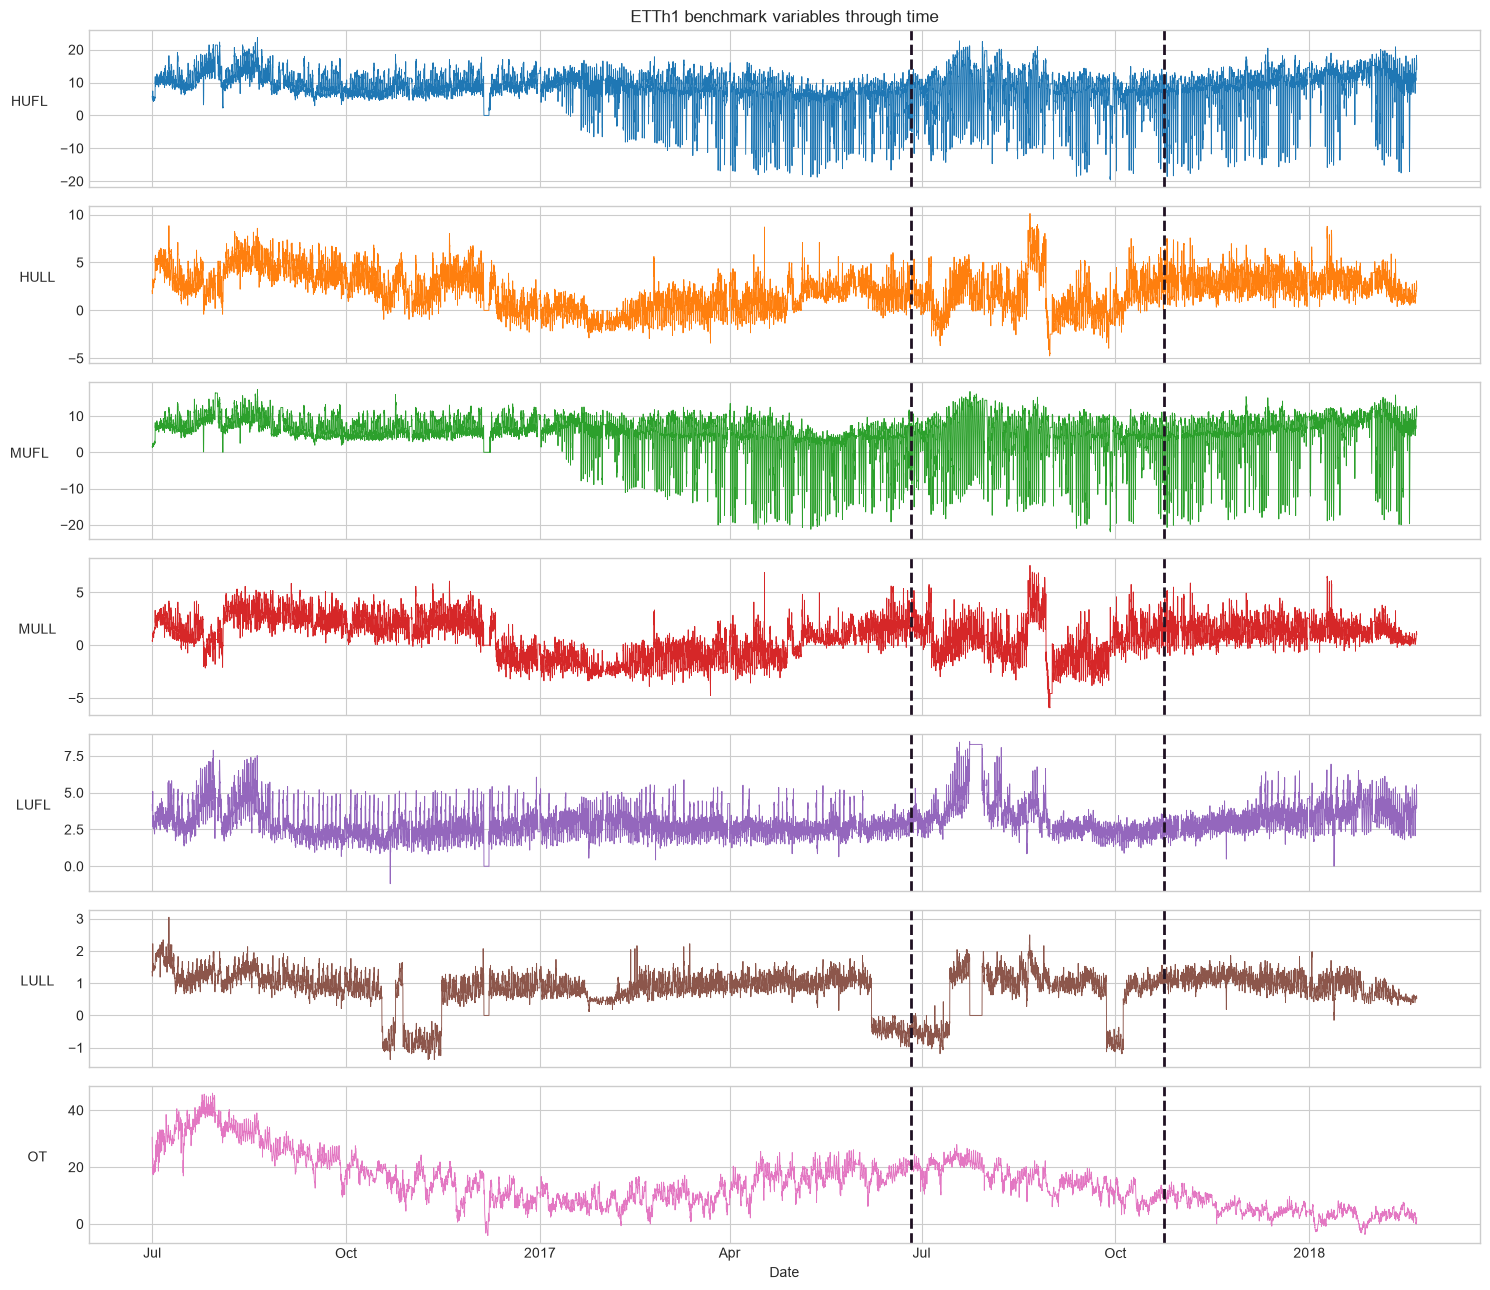

In [5]:
validation_start = splits["validation"].index[0]
test_start = splits["test"].index[0]

fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1, figsize=(15, 13), sharex=True)
colors = plt.cm.tab10(np.arange(len(FEATURE_COLUMNS)))

for ax, column, color in zip(axes, FEATURE_COLUMNS, colors):
    ax.plot(benchmark.index, benchmark[column], linewidth=0.65, color=color)
    ax.axvline(validation_start, color="#1f1123", linestyle="--", linewidth=2)
    ax.axvline(test_start, color="#1f1123", linestyle="--", linewidth=2)
    ax.set_ylabel(column, rotation=0, labelpad=22)

locator = mdates.AutoDateLocator(minticks=5, maxticks=9)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
axes[0].set_title("ETTh1 benchmark variables through time")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 6. Compare training, validation, and test distributions

**Purpose:** quantify whether later periods have different levels or variability from training. This matters because a model fitted on one distribution can struggle after a temporal shift.

The table reports original means and standard deviations. The plots express later splits relative to training:

- mean shift `0` means equal to the training mean;
- mean shift `1` means one training standard deviation above training;
- variability ratio `1` means equal standard deviation to training.

This comparison helps us describe dataset difficulty. It will not be used to fit preprocessing: all scaling parameters must be learned from training only.

train        validation          test       
        mean    std       mean    std   mean    std
HUFL   7.938  5.813      6.483  7.279  8.121  7.657
HULL   2.021  2.090      1.525  2.224  2.971  1.230
MUFL   5.080  5.519      3.434  7.234  4.766  7.429
MULL   0.746  1.926      0.370  2.011  1.457  1.014
LUFL   2.782  1.024      3.379  1.580  3.288  0.914
LULL   0.788  0.630      0.670  0.784  0.969  0.301
OT    17.128  9.177     15.578  4.975  4.850  3.149

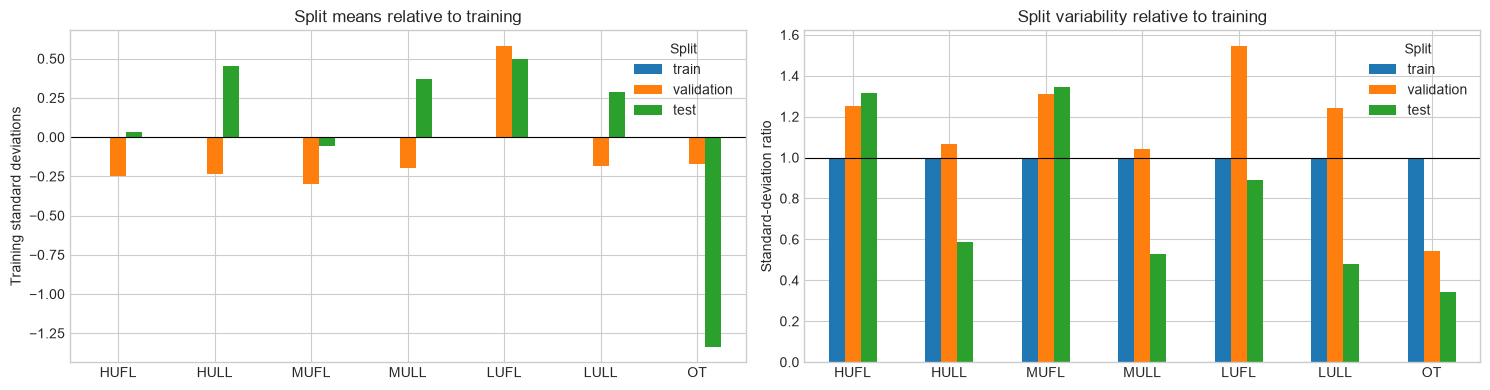

In [6]:
split_statistics = pd.concat(
    {name: part.agg(["mean", "std"]).T for name, part in splits.items()},
    axis=1,
)
display(split_statistics.round(3))

train_mean = train.mean()
train_std = train.std()
standardized_mean_shift = pd.DataFrame(
    {name: (part.mean() - train_mean) / train_std for name, part in splits.items()}
).T
standard_deviation_ratio = pd.DataFrame(
    {name: part.std() / train_std for name, part in splits.items()}
).T

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
standardized_mean_shift.T.plot(kind="bar", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Split means relative to training", ylabel="Training standard deviations")

standard_deviation_ratio.T.plot(kind="bar", ax=axes[1])
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set(title="Split variability relative to training", ylabel="Standard-deviation ratio")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Split")
plt.tight_layout()
plt.show()

## 7. Examine training distributions

A histogram ignores time order and counts how often different values occur.

- **Symmetric:** similar shape on both sides of its center.
- **Skewed:** one tail is longer than the other.
- **Multimodal:** the histogram contains two or more distinct peaks.

Multimodality describes the distribution of values, not repeated peaks through time. A daily peak in a time-series plot is seasonality. Repeated operating regimes can sometimes create multiple histogram modes, but the two concepts are not equivalent.

We use training data here so that model-design observations are not based on the test period.

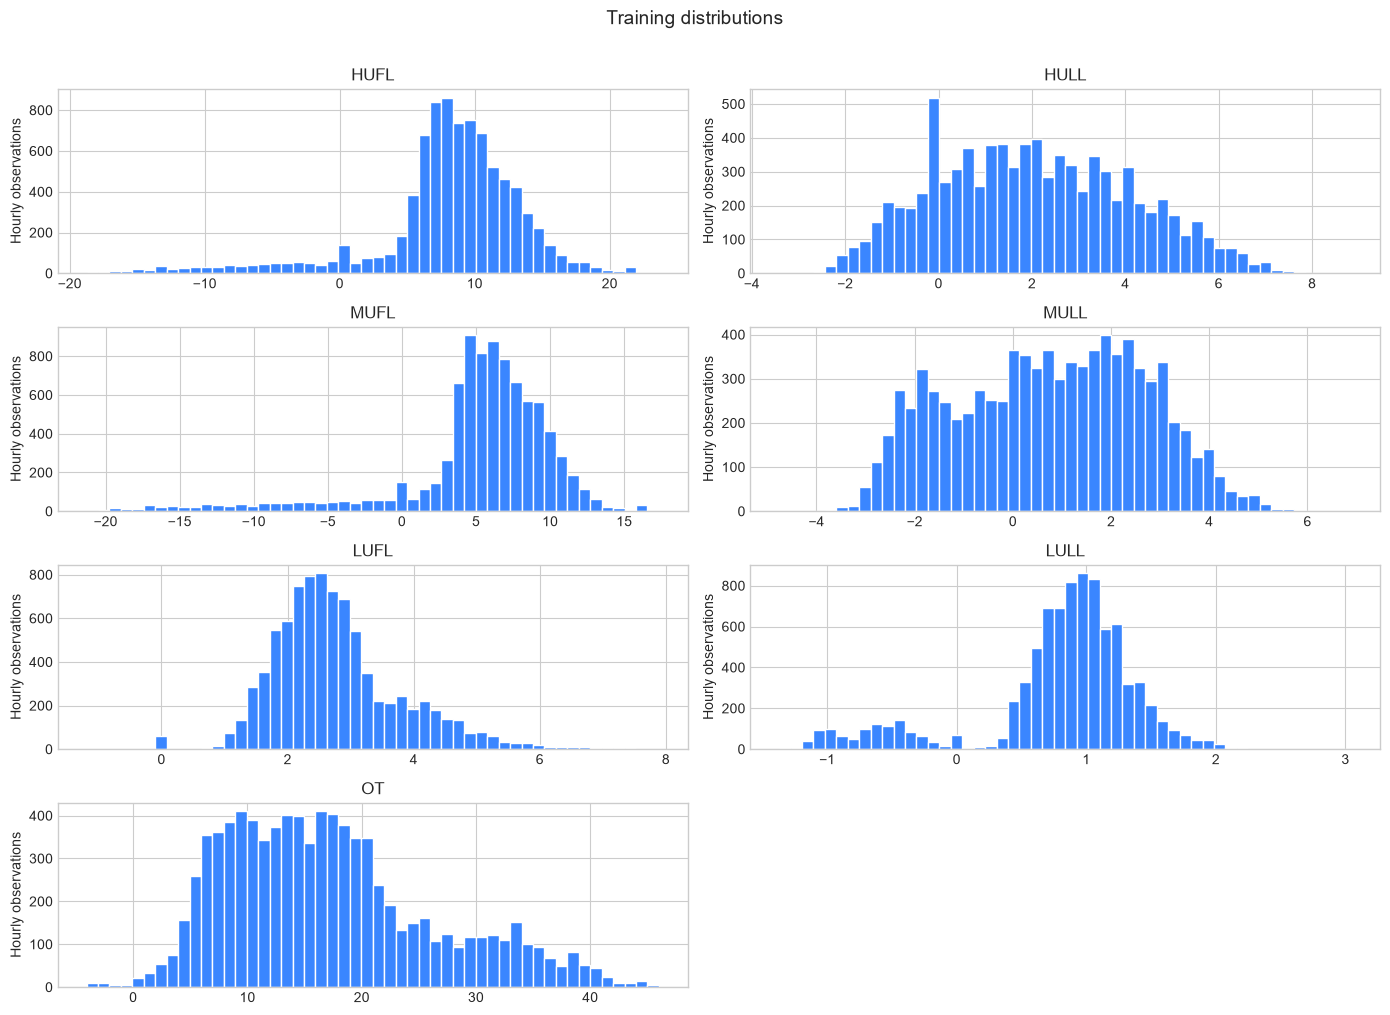

In [7]:
axes = train.hist(
    bins=50,
    figsize=(14, 10),
    color="#3a86ff",
    edgecolor="white",
    layout=(4, 2),
)
for ax in np.asarray(axes).ravel():
    ax.set_ylabel("Hourly observations")
plt.suptitle("Training distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Measure same-hour relationships between variables

**Pearson correlation** measures the strength of a linear relationship from `-1` to `1`:

- near `1`: the variables tend to increase together;
- near `-1`: one tends to increase while the other decreases;
- near `0`: little same-hour linear association.

Correlation does not establish causation, does not detect every nonlinear relationship, and says nothing about delayed effects. This first matrix compares channels only at the same timestamp and uses training data only.

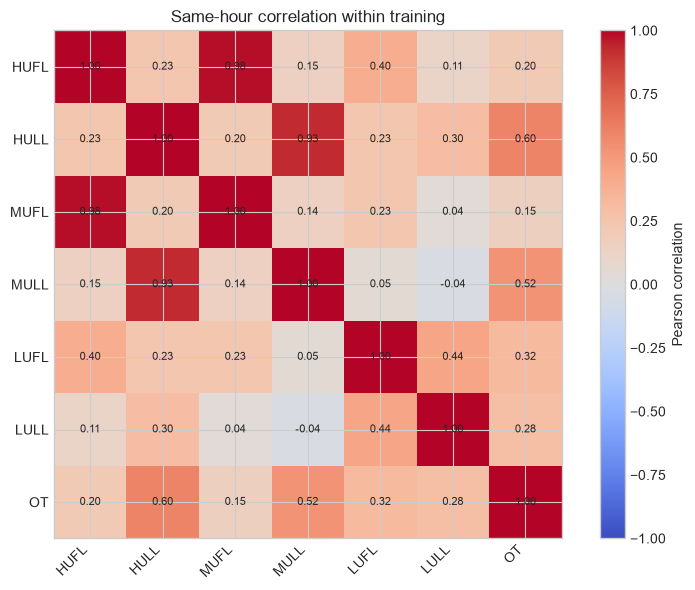

In [8]:
same_hour_correlation = train.corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(same_hour_correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS)), labels=FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLUMNS)), labels=FEATURE_COLUMNS)

for row in range(len(FEATURE_COLUMNS)):
    for column in range(len(FEATURE_COLUMNS)):
        ax.text(
            column,
            row,
            f"{same_hour_correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Same-hour correlation within training")
plt.tight_layout()
plt.show()

## 9. Look for calendar patterns in oil temperature

**Purpose:** check whether OT has a typical hour-of-day or weekday pattern. These are descriptive averages over training and do not represent every individual day.

A strong hourly pattern could support daily seasonal baselines or known calendar features. Weekday bars that are almost equal would suggest that weekday identity is less informative than hour of day.

Calendar features are safe only when constructed from timestamps that would be known at forecast time; future observed values remain forbidden.

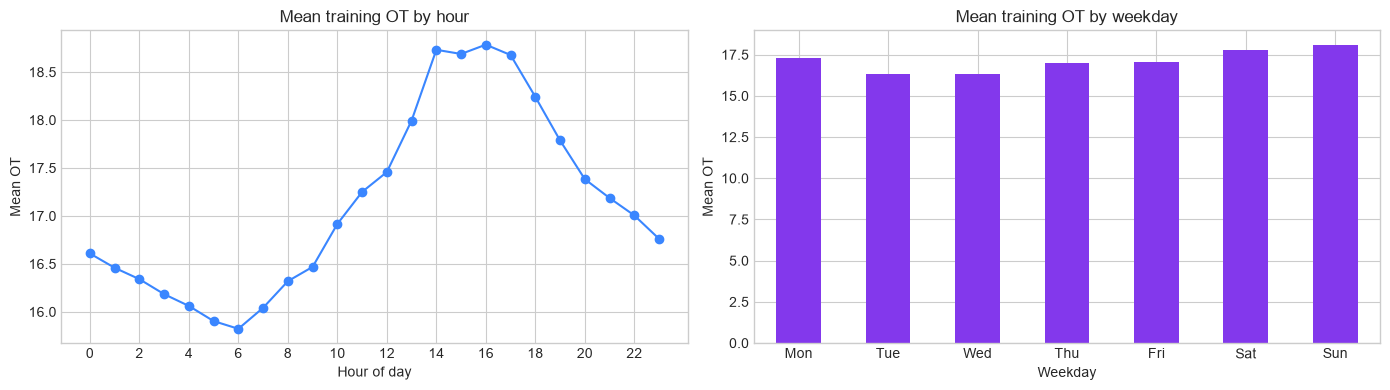

In [9]:
hourly_ot = train["OT"].groupby(train.index.hour).mean()
weekday_ot = train["OT"].groupby(train.index.dayofweek).mean()
weekday_ot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_ot.plot(ax=axes[0], marker="o", color="#3a86ff")
axes[0].set(title="Mean training OT by hour", xlabel="Hour of day", ylabel="Mean OT")
axes[0].set_xticks(range(0, 24, 2))

weekday_ot.plot(kind="bar", ax=axes[1], color="#8338ec", rot=0)
axes[1].set(title="Mean training OT by weekday", xlabel="Weekday", ylabel="Mean OT")
plt.tight_layout()
plt.show()

## 10. Measure autocorrelation at meaningful hourly lags

Autocorrelation compares each variable with its own earlier values:

- lag `1`: one hour earlier;
- lag `24`: the same hour one day earlier;
- lag `168`: the same hour one week earlier;
- lag `336`: two weeks earlier and our planned input length.

A high lag-24 value means that consecutive days tend to resemble one another at the same hour. It does not prove causality. The calculation uses training data only.

,1,24,168,336
HUFL,0.925,0.800,0.699,0.660
HULL,0.932,0.846,0.740,0.657
MUFL,0.928,0.807,0.717,0.683
MULL,0.934,0.868,0.784,0.715
LUFL,0.850,0.340,0.374,0.281
LULL,0.965,0.822,0.575,0.387
OT,0.993,0.929,0.853,0.839


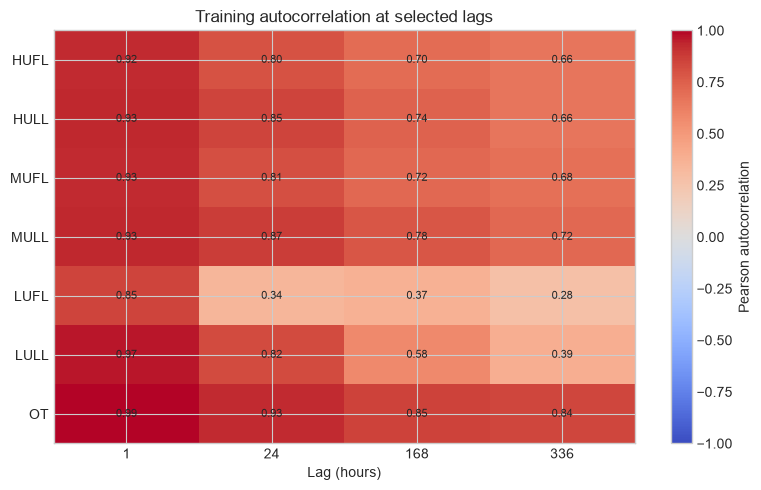

In [13]:
important_lags = [1, 24, 168, 336]
autocorrelation = pd.DataFrame(
    {
        lag: train.corrwith(train.shift(lag))
        for lag in important_lags
    }
)
display(autocorrelation.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(autocorrelation, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(important_lags)), labels=important_lags)
ax.set_yticks(range(len(FEATURE_COLUMNS)), labels=FEATURE_COLUMNS)
ax.set(xlabel="Lag (hours)", title="Training autocorrelation at selected lags")

for row in range(len(FEATURE_COLUMNS)):
    for column in range(len(important_lags)):
        ax.text(
            column,
            row,
            f"{autocorrelation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(image, ax=ax, label="Pearson autocorrelation")
plt.tight_layout()
plt.show()

## 11. Test whether earlier loads relate to later OT

The same-hour matrix cannot detect a delayed thermal relationship. Here, positive lag `k` means:

`load at time t - k` compared with `OT at time t`.

This is a **cross-channel lagged correlation**, not OT autocorrelation. It asks whether an earlier measurement from a different channel contains information about later oil temperature.

We test lags from 0 to 168 hours using training data. A strong value can motivate a forecasting experiment, but shared trends or seasonality may also create correlation. It neither proves causation nor guarantees that channel mixing will improve PatchTST.

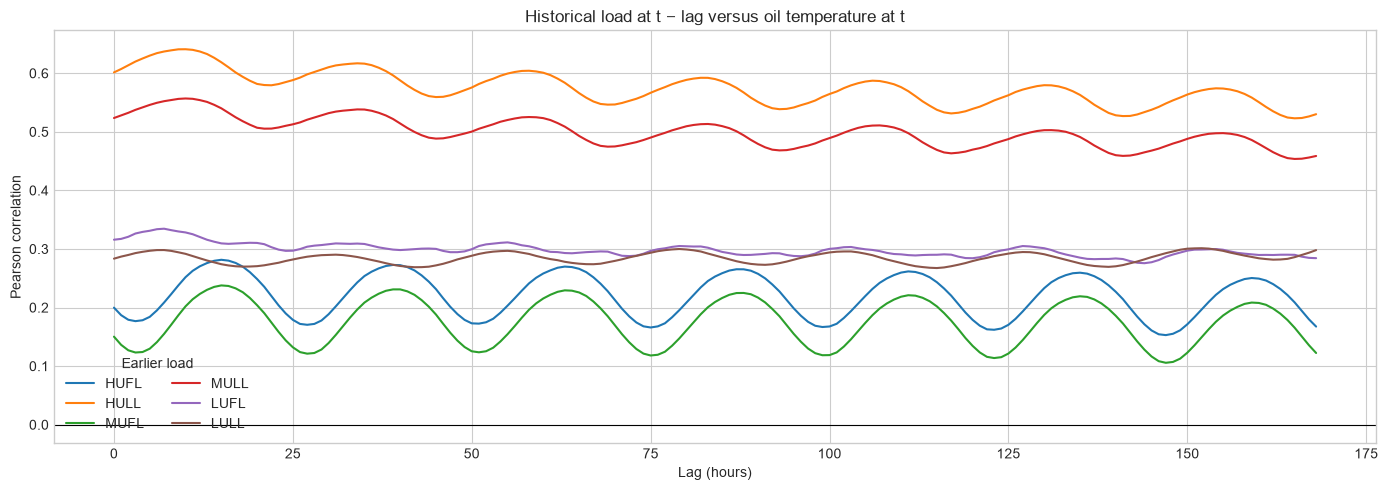

,strongest absolute lag (hours),correlation at that lag
HUFL,15,0.281
HULL,10,0.641
MUFL,15,0.238
MULL,10,0.557
LUFL,7,0.335
LULL,152,0.301


In [11]:
load_columns = [column for column in FEATURE_COLUMNS if column != "OT"]
candidate_lags = range(0, 169)

lagged_load_to_ot = pd.DataFrame(
    {
        column: [train[column].shift(lag).corr(train["OT"]) for lag in candidate_lags]
        for column in load_columns
    },
    index=candidate_lags,
)
lagged_load_to_ot.index.name = "lag_hours"

fig, ax = plt.subplots(figsize=(14, 5))
lagged_load_to_ot.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Historical load at t − lag versus oil temperature at t",
    xlabel="Lag (hours)",
    ylabel="Pearson correlation",
)
ax.legend(title="Earlier load", ncols=2)
plt.tight_layout()
plt.show()

strongest_lagged_relationship = pd.DataFrame(
    {
        "strongest absolute lag (hours)": lagged_load_to_ot.abs().idxmax(),
        "correlation at that lag": {
            column: lagged_load_to_ot.loc[lagged_load_to_ot[column].abs().idxmax(), column]
            for column in load_columns
        },
    }
)
display(strongest_lagged_relationship.round(3))

## 12. Understand one forecasting example

Our planned benchmark uses the previous **336 hours (14 days)** of all seven variables to forecast the next **96 hours (4 days)** of all seven variables.

The vertical line is the forecast origin:

- everything before it is model input;
- everything after it is the unknown target during forecasting;
- the validation target begins immediately after the training period;
- its input may use earlier training observations because those observations would already be known at that time.

DLinear and PatchTST will receive the same window shapes and target periods.

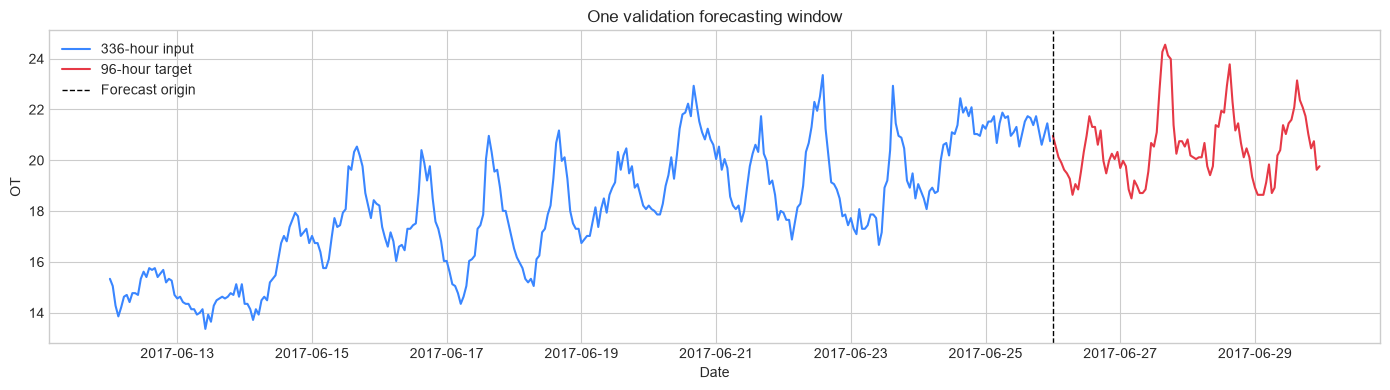

     train: 8,209 windows | input (336, 7) -> target (96, 7)
validation: 2,785 windows | input (336, 7) -> target (96, 7)
      test: 2,785 windows | input (336, 7) -> target (96, 7)


In [12]:
input_length = 336
prediction_length = 96
forecast_origin = TRAIN_ROWS

input_slice = benchmark.iloc[forecast_origin - input_length : forecast_origin]
target_slice = benchmark.iloc[forecast_origin : forecast_origin + prediction_length]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(input_slice.index, input_slice["OT"], label="336-hour input", color="#3a86ff")
ax.plot(target_slice.index, target_slice["OT"], label="96-hour target", color="#e63946")
ax.axvline(target_slice.index[0], color="black", linestyle="--", linewidth=1, label="Forecast origin")
ax.set(title="One validation forecasting window", ylabel="OT", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

window_counts = {
    "train": TRAIN_ROWS - input_length - prediction_length + 1,
    "validation": VALIDATION_ROWS - prediction_length + 1,
    "test": TEST_ROWS - prediction_length + 1,
}

for name, count in window_counts.items():
    print(
        f"{name:>10}: {count:,} windows | "
        f"input ({input_length}, {len(FEATURE_COLUMNS)}) -> "
        f"target ({prediction_length}, {len(FEATURE_COLUMNS)})"
    )

## 13. Main conclusions and connection to the project

### What this EDA establishes

1. **The file is suitable for hourly forecasting.** It contains 17,420 sorted hourly rows, seven numeric variables, and no missing or duplicated observations.
2. **The benchmark must remain chronological.** Training, validation, and test contain 8,640, 2,880, and 2,880 target hours respectively.
3. **The splits are not identically distributed.** In particular, test OT is substantially lower and less variable than training OT. This makes the benchmark realistic and difficult.
4. **The variables are temporally persistent.** OT has especially strong autocorrelation at daily, weekly, and two-week lags.
5. **Hour of day appears more informative than weekday.** This supports a daily seasonal-naive baseline and makes calendar information a plausible controlled feature experiment.
6. **Some delayed cross-channel relationships are stronger than same-hour relationships.** Earlier HULL and MULL values show their strongest training correlations with later OT at roughly ten hours. This gives a data-based reason to test controlled channel mixing in PatchTST.

### What this EDA does not establish

- Correlation is not causation.
- A correlation does not guarantee lower forecasting error.
- We have not selected an improvement using test metrics.
- We have not yet reconstructed either paper.